In [2]:
import numpy as np

t_mid = np.array([
  0.0, 6.348, 14.39, 15.099, 15.548, 16.821, 17.341, 17.648, 17.82, 18.185,
  18.647, 20.433, 20.836, 21.554, 22.212, 22.728, 22.985, 24.215, 25.597,
  25.942, 26.489, 26.738, 27.252, 27.403, 27.557, 28.019, 28.712, 29.102,
  29.373, 29.91, 31.369, 31.757, 32.395, 38.511, 39.062, 40.274, 42.928,
  45.357, 46.238, 49.915
])

alpha = np.array([
    -0.16, -0.43, -0.46, -0.49, -0.59, -0.62, -0.66, -0.46, -0.47, -0.60,
    -0.61, -0.64, -0.66, -0.65, -0.56, -0.65, -0.65, -0.62, -0.69, -0.75,
    -0.71, -0.72, -0.54, -0.63, -0.71, -0.77, -0.77, -0.69, -0.72, -0.59,
    -0.79, -0.67, -0.86, -0.83, -0.81, -0.93, -0.86, -0.94, -1.00, -1.00
])

alpha_err_plus = np.array([
     0.11, 0.06, 0.09, 0.08, 0.03, 0.06, 0.05, 0.04, 0.05, 0.03,
     0.01, 0.03, 0.02, 0.03, 0.05, 0.07, 0.04, 0.06, 0.06, 0.11,
     0.07, 0.06, 0.07, 0.04, 0.05, 0.04, 0.08, 0.05, 0.05, 0.09,
     0.11, 0.15, 0.09, 0.09, 0.14, 0.14, 0.24, 0.14, 0.23, 0.19
])

alpha_err_minus = np.array([
     0.11, 0.05, 0.09, 0.08, 0.03, 0.03, 0.06, 0.06, 0.06, 0.03,
     0.02, 0.03, 0.03, 0.03, 0.05, 0.06, 0.05, 0.05, 0.08, 0.11,
     0.05, 0.05, 0.15, 0.06, 0.04, 0.05, 0.07, 0.06, 0.12, 0.11,
     0.09, 0.12, 0.09, 0.09, 0.10, 0.10, 0.15, 0.11, 0.10, 0.11
])


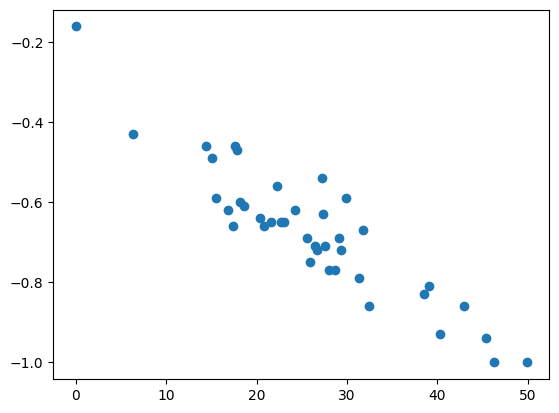

In [3]:
import matplotlib.pyplot as plt

plt.scatter(t_mid, alpha)

In [4]:
import numpy as np
from scipy.optimize import curve_fit

# your arrays from the table:
# t_mid, alpha, alpha_err_plus, alpha_err_minus

# make a symmetric 1σ error for alpha (simple, standard choice)
sigma = 0.5 * (alpha_err_plus + alpha_err_minus)
sigma = np.where(sigma > 0, sigma, np.min(sigma[sigma>0]))  # guard zeros

def lin(x, m, b):
    return m*x + b

popt, pcov = curve_fit(lin, t_mid, alpha, sigma=sigma, absolute_sigma=True)
m, b = popt
dm, db = np.sqrt(np.diag(pcov))  # 1σ uncertainties

# goodness-of-fit
resid = alpha - lin(t_mid, m, b)
chi2 = np.sum((resid/sigma)**2)
dof = len(alpha) - 2
chi2_red = chi2 / dof

print(f"alpha(t) = ({m:.4g} ± {dm:.4g}) * t  +  ({b:.4g} ± {db:.4g})")
print(f"chi2 = {chi2:.2f}, dof = {dof}, chi2_red = {chi2_red:.2f}")

alpha(t) = (-0.01281 ± 0.001308) * t  +  (-0.361 ± 0.0286)
chi2 = 38.58, dof = 38, chi2_red = 1.02


In [5]:
get_fit = lin(t_mid,m,b)

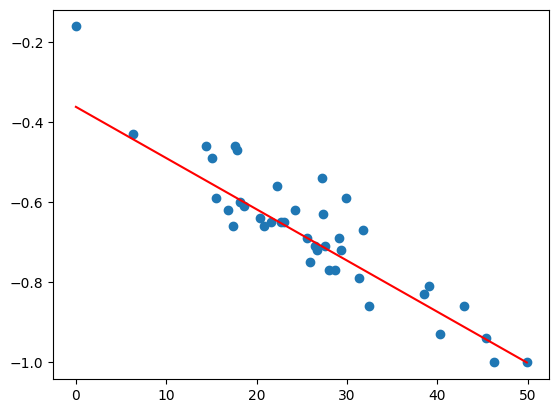

In [6]:
plt.scatter(t_mid, alpha)
plt.plot(t_mid, get_fit, c='r')

In [7]:
import numpy as np
from scipy.optimize import curve_fit

# your arrays from the table:
# t_mid, alpha, alpha_err_plus, alpha_err_minus

# make a symmetric 1σ error for alpha (simple, standard choice)
sigma = 0.5 * (alpha_err_plus + alpha_err_minus)
sigma = np.where(sigma > 0, sigma, np.min(sigma[sigma>0]))  # guard zeros

def lin(x, m, b):
    return m*x + b

popt, pcov = curve_fit(lin, t_mid, alpha, sigma=sigma, absolute_sigma=True)
m, b = popt
dm, db = np.sqrt(np.diag(pcov))  # 1σ uncertainties

# goodness-of-fit
resid = alpha - lin(t_mid, m, b)
chi2 = np.sum((resid/sigma)**2)
dof = len(alpha) - 2
chi2_red = chi2 / dof

print(f"beta(t) = ({m:.4g} ± {dm:.4g}) * t  +  ({b:.4g} ± {db:.4g})")
print(f"chi2 = {chi2:.2f}, dof = {dof}, chi2_red = {chi2_red:.2f}")

beta(t) = (-0.01281 ± 0.001308) * t  +  (-0.361 ± 0.0286)
chi2 = 38.58, dof = 38, chi2_red = 1.02


In [8]:
get_fit = lin(t_mid,m,b)

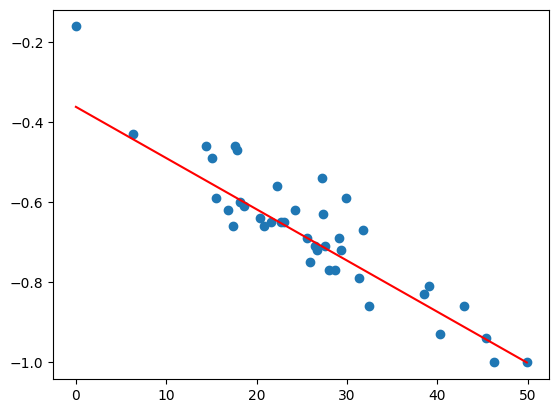

In [9]:
plt.scatter(t_mid, alpha)
plt.plot(t_mid, get_fit, c='r')

In [10]:
import emcee
from multiprocess import Pool

You must install the tqdm library to use progress indicators with emcee


alpha(t) = (-0.01243 +0.0011/-0.0012) * t  +  (-0.3646 +0.029/-0.026)
Intrinsic scatter (1σ) ≈ 4.4e-05 [+0.017/-4.4e-05]


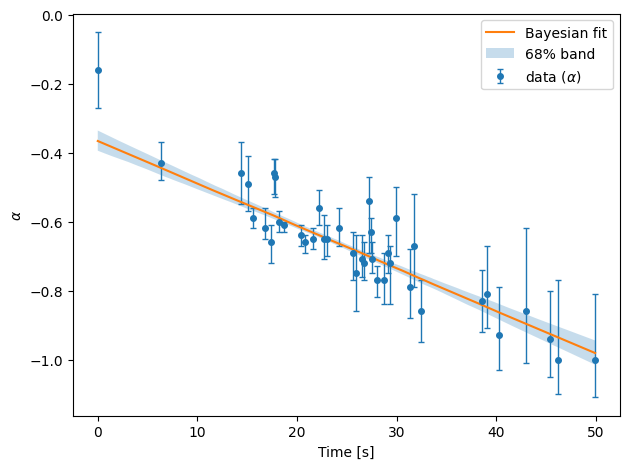

In [11]:
# pip install emcee corner  # (once, in your environment)

import numpy as np
import emcee
import matplotlib.pyplot as plt
try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False

# -----------------------------
# 1) YOUR DATA (fill these)
# -----------------------------
# t_mid, alpha, alpha_err_plus, alpha_err_minus = ...

# basic sanity guards
alpha_err_plus  = np.asarray(alpha_err_plus,  dtype=float)
alpha_err_minus = np.asarray(alpha_err_minus, dtype=float)
t_mid           = np.asarray(t_mid,           dtype=float)
alpha           = np.asarray(alpha,           dtype=float)

# avoid zero/neg errors
eps = 1e-12
alpha_err_plus  = np.where(alpha_err_plus  > 0, alpha_err_plus,  np.nanmin(alpha_err_plus [alpha_err_plus >0])*0.5)
alpha_err_minus = np.where(alpha_err_minus > 0, alpha_err_minus, np.nanmin(alpha_err_minus[alpha_err_minus>0])*0.5)

# -----------------------------
# 2) Split-normal likelihood
# -----------------------------
def loglike(theta, x, y, yerr_p, yerr_m):
    m, b, logs = theta
    s_int = np.exp(logs)  # intrinsic scatter in y (optional; set logs=-inf to disable)
    mu = m*x + b
    # choose sigma_plus if residual >= 0, else sigma_minus
    sigma = np.where(y >= mu, yerr_p, yerr_m)
    sigma = np.sqrt(sigma**2 + s_int**2)
    z = (y - mu) / sigma
    return -0.5*np.sum(z*z + 2*np.log(sigma) + np.log(2*np.pi))

# -----------------------------
# 3) Priors (weakly-informative)
# -----------------------------
def logprior(theta):
    m, b, logs = theta
    # broad, proper priors
    if not (-1000 < m < 1000):   return -np.inf
    if not (-1e4  < b < 1e4):    return -np.inf
    if not (-20   < logs < 5):   return -np.inf
    # weak Gaussian pull to keep numerics happy (optional)
    lp = -0.5*(m/100.0)**2 - 0.5*(b/1000.0)**2
    # flat on log s_int (Jeffreys-like over s_int)
    return lp

def logpost(theta, x, y, yerr_p, yerr_m):
    lp = logprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = loglike(theta, x, y, yerr_p, yerr_m)
    return lp + ll

# -----------------------------
# 4) Initialize near WLS
# -----------------------------
# symmetric errors for an initial guess
sigma_sym = 0.5*(alpha_err_plus + alpha_err_minus)
sigma_sym = np.where(sigma_sym>0, sigma_sym, np.nanmin(sigma_sym[sigma_sym>0])*0.5)
coef = np.polyfit(t_mid, alpha, 1, w=1.0/sigma_sym)
m0, b0 = coef[0], coef[1]
logs0 = np.log(np.median(sigma_sym)*0.1)  # small intrinsic scatter to start
theta0 = np.array([m0, b0, logs0])

ndim, nwalkers = 3, 32
p0 = theta0 + 1e-4*np.random.randn(nwalkers, ndim)

# -----------------------------
# 5) Run MCMC
# -----------------------------
sampler = emcee.EnsembleSampler(nwalkers, ndim, logpost, args=(t_mid, alpha, alpha_err_plus, alpha_err_minus), pool=Pool())
sampler.run_mcmc(p0, 3000, progress=True)
burn, thin = 1000, 5
flat = sampler.get_chain(discard=burn, thin=thin, flat=True)

m_med, b_med, logs_med = np.median(flat, axis=0)
m_lo,  b_lo,  logs_lo  = np.percentile(flat, 16, axis=0)
m_hi,  b_hi,  logs_hi  = np.percentile(flat, 84, axis=0)

print(f"alpha(t) = ({m_med:.4g} +{m_hi-m_med:.2g}/-{m_med-m_lo:.2g}) * t  +  "
      f"({b_med:.4g} +{b_hi-b_med:.2g}/-{b_med-b_lo:.2g})")
print(f"Intrinsic scatter (1σ) ≈ {np.exp(logs_med):.3g} "
      f"[+{np.exp(logs_hi)-np.exp(logs_med):.2g}/-{np.exp(logs_med)-np.exp(logs_lo):.2g}]")

# -----------------------------
# 6) Plots (fit + 1σ band)
# -----------------------------
xx = np.linspace(t_mid.min(), t_mid.max(), 400)
# draw predictive lines from posterior for band
idx = np.random.choice(len(flat), size=200, replace=False)
yy = np.array([flat[k,0]*xx + flat[k,1] for k in idx])
y_med = np.median(yy, axis=0)
y_lo, y_hi = np.percentile(yy, [16,84], axis=0)

plt.errorbar(t_mid, alpha,
             yerr=[alpha_err_minus, alpha_err_plus],
             fmt='o', ms=4, elinewidth=1, capsize=2, label=r'data ($\alpha$)')
plt.plot(xx, y_med, label='Bayesian fit')
plt.fill_between(xx, y_lo, y_hi, alpha=0.25, label='68% band')
plt.xlabel('Time [s]')
plt.ylabel(r'$\alpha$')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Corner plot (optional)
# -----------------------------
if HAS_CORNER:
    corner.corner(flat, labels=[r'$m$', r'$b$', r'$\ln s_{\rm int}$'],
                  show_titles=True, title_fmt=".3g")
    plt.show()


In [12]:
import numpy as np

beta = np.array([
    -2.36, -2.81, -2.42, -2.57, -2.68, -2.70, -2.48, -2.34, -2.37,
    -2.39, -2.55, -2.52, -2.68, -2.73, -2.26, -2.70, -2.35, -2.67,
    -2.52, -2.02, -2.60, -2.69, -2.20, -2.28, -2.68, -2.43, -2.56, -2.62,
    -2.36, -2.14, -2.46, -2.26, -2.43, -2.43, -2.07, -2.17, -2.25,
    -2.75, -2.63, -2.71
])

# +1σ (upper) errors
beta_err_plus = np.array([
    0.13, 0.22, 0.15, 0.16, 0.08, 0.12, 0.11, 0.08, 0.09,
    0.07, 0.04, 0.09, 0.11, 0.09, 0.08, 0.17, 0.10, 0.17,
    0.15, 0.1, 0.23, 0.20, 0.07, 0.08, 0.13, 0.12, 0.20, 0.18,
    0.10, 0.08, 0.20, 0.15, 0.13, 0.18, 0.09, 0.09, 0.09,
    0.21, 0.21, 0.19
])

# −1σ (lower) errors (as positive magnitudes)
beta_err_minus = np.array([
    0.33, 0.32, 0.33, 0.34, 0.21, 0.39, 0.30, 0.15, 0.17,
    0.10, 0.06, 0.15, 0.19, 0.23, 0.11, 0.36, 0.20, 0.35,
    0.43, 0.27, 0.28, 0.33, 0.47, 0.17, 0.39, 0.26, 0.35, 0.28,
    0.51, 0.16, 0.42, 0.41, 0.30, 0.42, 0.12, 0.19, 0.24,
    0.38, 0.31, 0.35
])


You must install the tqdm library to use progress indicators with emcee


beta(t) = (0.006904 +0.0033/-0.0035) * t  +  (-2.557 +0.08/-0.078)
Intrinsic scatter (1σ) ≈ 0.11 [+0.044/-0.055]


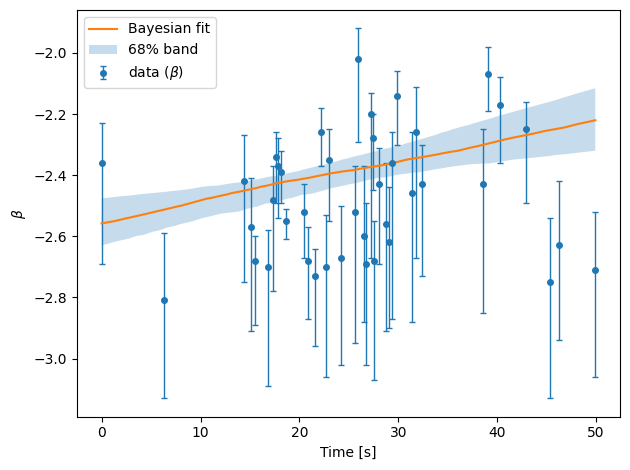

In [13]:
# pip install emcee corner  # (once, in your environment)

import numpy as np
import emcee
import matplotlib.pyplot as plt
try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False

# -----------------------------
# 1) YOUR DATA (fill these)
# -----------------------------
# t_mid, alpha, alpha_err_plus, alpha_err_minus = ...

# basic sanity guards
beta_err_plus  = np.asarray(beta_err_plus,  dtype=float)
beta_err_minus = np.asarray(beta_err_minus, dtype=float)
t_mid           = np.asarray(t_mid,           dtype=float)
beta           = np.asarray(beta,           dtype=float)

# avoid zero/neg errors
eps = 1e-12
beta_err_plus  = np.where(beta_err_plus  > 0, beta_err_plus,  np.nanmin(beta_err_plus [beta_err_plus >0])*0.5)
beta_err_minus = np.where(beta_err_minus > 0, beta_err_minus, np.nanmin(beta_err_minus[beta_err_minus>0])*0.5)

# -----------------------------
# 2) Split-normal likelihood
# -----------------------------
def loglike(theta, x, y, yerr_p, yerr_m):
    m, b, logs = theta
    s_int = np.exp(logs)  # intrinsic scatter in y (optional; set logs=-inf to disable)
    mu = m*x + b
    # choose sigma_plus if residual >= 0, else sigma_minus
    sigma = np.where(y >= mu, yerr_p, yerr_m)
    sigma = np.sqrt(sigma**2 + s_int**2)
    z = (y - mu) / sigma
    return -0.5*np.sum(z*z + 2*np.log(sigma) + np.log(2*np.pi))

# -----------------------------
# 3) Priors (weakly-informative)
# -----------------------------
def logprior(theta):
    m, b, logs = theta
    # broad, proper priors
    if not (-1000 < m < 1000):   return -np.inf
    if not (-1e4  < b < 1e4):    return -np.inf
    if not (-20   < logs < 5):   return -np.inf
    # weak Gaussian pull to keep numerics happy (optional)
    lp = -0.5*(m/100.0)**2 - 0.5*(b/1000.0)**2
    # flat on log s_int (Jeffreys-like over s_int)
    return lp

def logpost(theta, x, y, yerr_p, yerr_m):
    lp = logprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = loglike(theta, x, y, yerr_p, yerr_m)
    return lp + ll

# -----------------------------
# 4) Initialize near WLS
# -----------------------------
# symmetric errors for an initial guess
sigma_sym = 0.5*(beta_err_plus + beta_err_minus)
sigma_sym = np.where(sigma_sym>0, sigma_sym, np.nanmin(sigma_sym[sigma_sym>0])*0.5)
coef = np.polyfit(t_mid, beta, 1, w=1.0/sigma_sym)
m0, b0 = coef[0], coef[1]
logs0 = np.log(np.median(sigma_sym)*0.1)  # small intrinsic scatter to start
theta0 = np.array([m0, b0, logs0])

ndim, nwalkers = 3, 32
p0 = theta0 + 1e-4*np.random.randn(nwalkers, ndim)

# -----------------------------
# 5) Run MCMC
# -----------------------------
sampler = emcee.EnsembleSampler(nwalkers, ndim, logpost, args=(t_mid, beta, beta_err_plus, beta_err_minus), pool=Pool())
sampler.run_mcmc(p0, 3000, progress=True)
burn, thin = 1000, 5
flat = sampler.get_chain(discard=burn, thin=thin, flat=True)

m_med, b_med, logs_med = np.median(flat, axis=0)
m_lo,  b_lo,  logs_lo  = np.percentile(flat, 16, axis=0)
m_hi,  b_hi,  logs_hi  = np.percentile(flat, 84, axis=0)

print(f"beta(t) = ({m_med:.4g} +{m_hi-m_med:.2g}/-{m_med-m_lo:.2g}) * t  +  "
      f"({b_med:.4g} +{b_hi-b_med:.2g}/-{b_med-b_lo:.2g})")
print(f"Intrinsic scatter (1σ) ≈ {np.exp(logs_med):.3g} "
      f"[+{np.exp(logs_hi)-np.exp(logs_med):.2g}/-{np.exp(logs_med)-np.exp(logs_lo):.2g}]")

# -----------------------------
# 6) Plots (fit + 1σ band)
# -----------------------------
xx = np.linspace(t_mid.min(), t_mid.max(), 400)
# draw predictive lines from posterior for band
idx = np.random.choice(len(flat), size=200, replace=False)
yy = np.array([flat[k,0]*xx + flat[k,1] for k in idx])
y_med = np.median(yy, axis=0)
y_lo, y_hi = np.percentile(yy, [16,84], axis=0)

plt.errorbar(t_mid, beta,
             yerr=[beta_err_minus, beta_err_plus],
             fmt='o', ms=4, elinewidth=1, capsize=2, label=r'data ($\beta$)')
plt.plot(xx, y_med, label='Bayesian fit')
plt.fill_between(xx, y_lo, y_hi, alpha=0.25, label='68% band')
plt.xlabel('Time [s]')
plt.ylabel(r'$\beta$')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Corner plot (optional)
# -----------------------------
if HAS_CORNER:
    corner.corner(flat, labels=[r'$m$', r'$b$', r'$\ln s_{\rm int}$'],
                  show_titles=True, title_fmt=".3g")
    plt.show()


In [14]:
a = -0.01253*t - 0.3616
b = 0.006867*t - 2.557

NameError: name 't' is not defined